In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
df = pd.read_csv("/content/drive/MyDrive/DV/healthcare_dataset.csv")

In [5]:
print("First 5 rows:")
print(df.head())

print("\nDataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())


First 5 rows:
            Name  Age  Gender Blood Type Medical Condition Date of Admission  \
0  Bobby JacksOn   30    Male         B-            Cancer        2024-01-31   
1   LesLie TErRy   62    Male         A+           Obesity        2019-08-20   
2    DaNnY sMitH   76  Female         A-           Obesity        2022-09-22   
3   andrEw waTtS   28  Female         O+          Diabetes        2020-11-18   
4  adrIENNE bEll   43  Female        AB+            Cancer        2022-09-19   

             Doctor                    Hospital Insurance Provider  \
0     Matthew Smith             Sons and Miller         Blue Cross   
1   Samantha Davies                     Kim Inc           Medicare   
2  Tiffany Mitchell                    Cook PLC              Aetna   
3       Kevin Wells  Hernandez Rogers and Vang,           Medicare   
4    Kathleen Hanna                 White-White              Aetna   

   Billing Amount  Room Number Admission Type Discharge Date   Medication  \
0    18

In [13]:
df["Date of Admission"] = pd.to_datetime(
    df["Date of Admission"],
    errors="coerce"
)


In [14]:
df["Hospital Stay"] = (
    pd.to_datetime(df["Discharge Date"], errors="coerce")
    - df["Date of Admission"]
).dt.days

** 1. STACKED BAR CHART
 Billing Amount by Medical Condition and Insurance Provider**

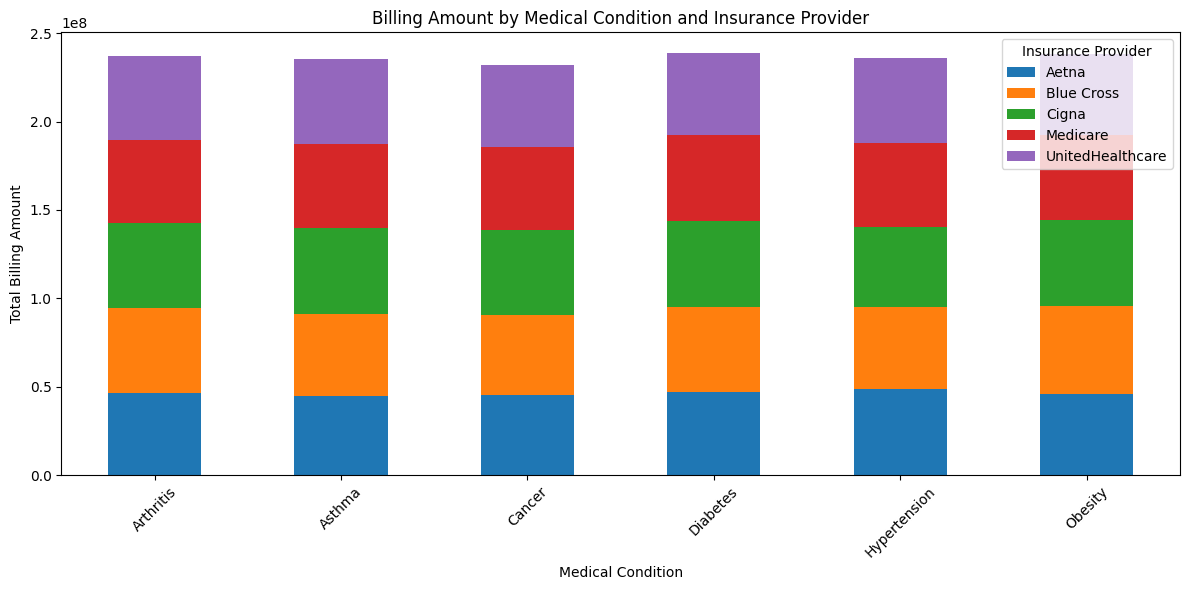

In [16]:

billing = pd.pivot_table(
    df,
    values="Billing Amount",
    index="Medical Condition",
    columns="Insurance Provider",
    aggfunc="sum",
    fill_value=0
)

billing.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)
plt.title("Billing Amount by Medical Condition and Insurance Provider")
plt.xlabel("Medical Condition")
plt.ylabel("Total Billing Amount")
plt.xticks(rotation=45)
plt.legend(title="Insurance Provider")
plt.tight_layout()
plt.show()


** 2. VIOLIN PLOT
Billing Amount across Medical Conditions**

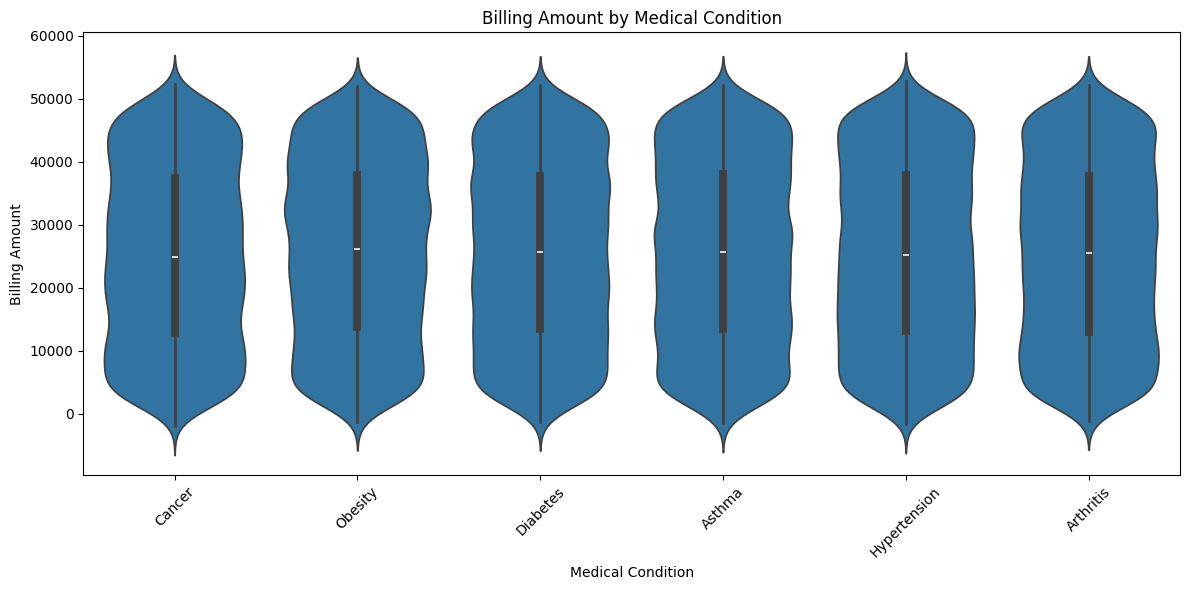

In [17]:

plt.figure(figsize=(12, 6))

sns.violinplot(
    data=df,
    x="Medical Condition",
    y="Billing Amount"
)

plt.title("Billing Amount by Medical Condition")
plt.xlabel("Medical Condition")
plt.ylabel("Billing Amount")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**3. VIOLIN PLOT
 Billing Amount across Insurance Providers**

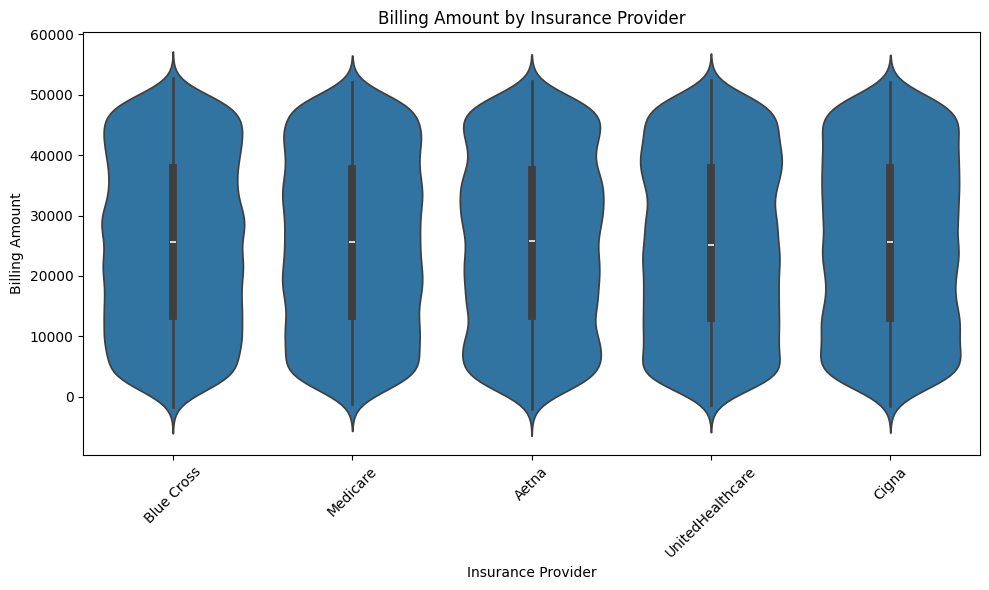

In [18]:
plt.figure(figsize=(10, 6))

sns.violinplot(
    data=df,
    x="Insurance Provider",
    y="Billing Amount"
)

plt.title("Billing Amount by Insurance Provider")
plt.xlabel("Insurance Provider")
plt.ylabel("Billing Amount")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**4. TEMPORAL LINE CHART
Patient Admissions over Time**

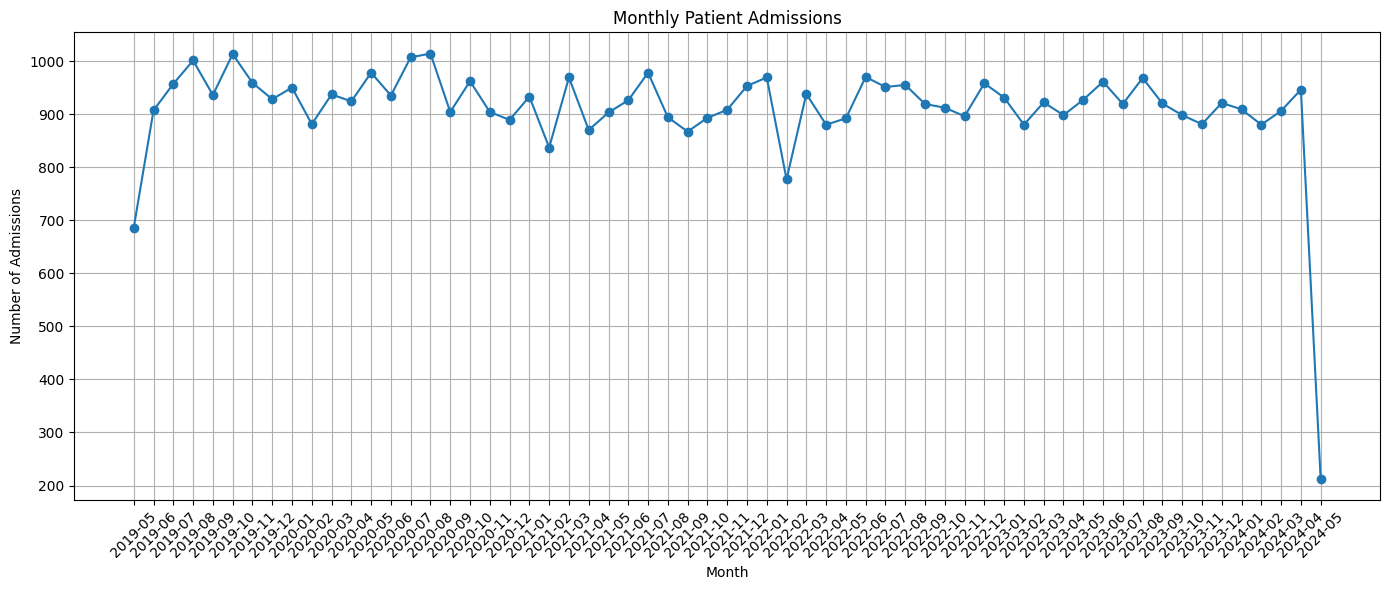

In [19]:

monthly_admissions = (
    df.groupby(
        df["Date of Admission"].dt.to_period("M")
    )
    .size()
)

monthly_admissions.index = monthly_admissions.index.astype(str)

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_admissions.index,
    monthly_admissions.values,
    marker="o"
)

plt.title("Monthly Patient Admissions")
plt.xlabel("Month")
plt.ylabel("Number of Admissions")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


**5. CORRELATION MATRIX
Age, Stay Duration and Total Medical Cost**

In [20]:
correlation = df[
    ["Age", "Hospital Stay", "Billing Amount"]
].corr()

print("Correlation Matrix:")
print(correlation)


Correlation Matrix:
                     Age  Hospital Stay  Billing Amount
Age             1.000000       0.008220       -0.003832
Hospital Stay   0.008220       1.000000       -0.005602
Billing Amount -0.003832      -0.005602        1.000000


**6. CORRELATION HEATMAP**

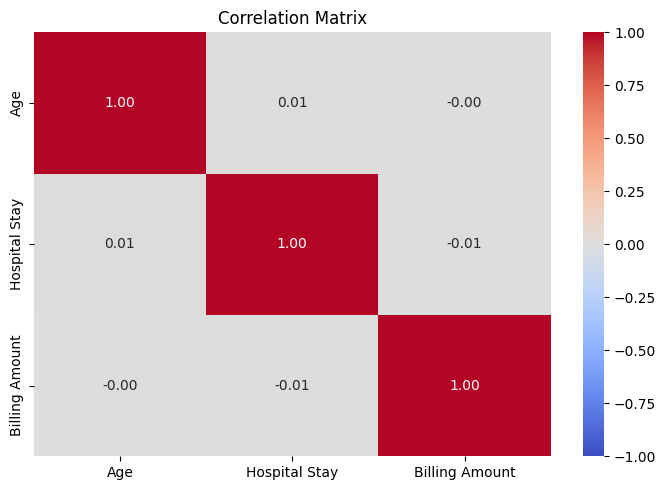

In [21]:

plt.figure(figsize=(7, 5))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()